# Term Structure and Interest Rate Risk

This notebook introduces the term structure of interest rates and shows how changes in yields affect bond prices.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

## Sample Yield Curve

We create a simple yield curve across different maturities.

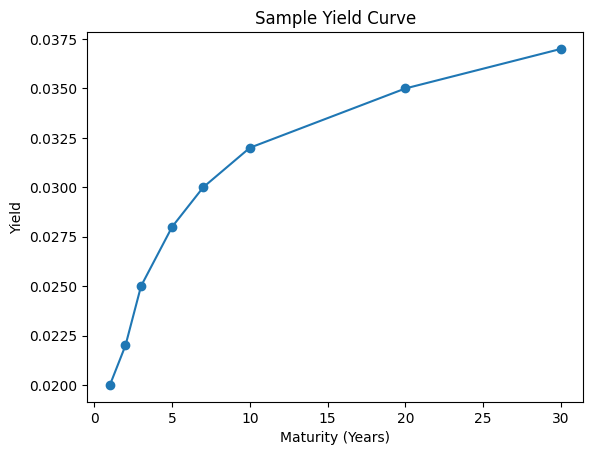

In [7]:
maturities = np.array([1, 2, 3, 5, 7, 10, 20, 30])
yields = np.array([0.02, 0.022, 0.025, 0.028, 0.03, 0.032, 0.035, 0.037])

plt.plot(maturities, yields, marker='o')
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield")
plt.title("Sample Yield Curve")
plt.show()

## Interest Rate Shock

We compare bond prices before and after an upward shift in yields.

In [8]:
def bond_price(face_value, coupon_rate, yield_rate, maturity):
    coupon = face_value * coupon_rate
    price = 0

    for t in range(1, maturity + 1):
        price += coupon / (1 + yield_rate) ** t

    price += face_value / (1 + yield_rate) ** maturity
    return price

In [9]:
price_before = bond_price(1000, 0.05, 0.03, 10)
price_after = bond_price(1000, 0.05, 0.04, 10)

print("Bond Price before rate increase:", round(price_before, 2))
print("Bond Price after rate increase:", round(price_after, 2))

Bond Price before rate increase: 1170.6
Bond Price after rate increase: 1081.11


## Sensitivity Comparison

Longer maturity bonds are generally more sensitive to interest rate changes.

In [10]:
short_bond_before = bond_price(1000, 0.05, 0.03, 2)
short_bond_after = bond_price(1000, 0.05, 0.04, 2)

long_bond_before = bond_price(1000, 0.05, 0.03, 15)
long_bond_after = bond_price(1000, 0.05, 0.04, 15)

print("Short bond price change:", round(short_bond_before - short_bond_after, 2))
print("Long bond price change:", round(long_bond_before - long_bond_after, 2))

Short bond price change: 19.41
Long bond price change: 127.57
